In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# PyTorch Dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
# Load data
current_dir = os.getcwd()
path_train = current_dir + "/../dataset/mitbih/" + "mitbih_train.csv"
path_test = current_dir + "/../dataset/mitbih/" + "mitbih_test.csv"

df_train = pd.read_csv(path_train, header=None)
df_test = pd.read_csv(path_test, header=None)

df_train.rename(columns={187:"Class"}, inplace=True)
df_test.rename(columns={187:"Class"}, inplace=True)

print("Dataset after resample")
print("Training set")
print(df_train.shape)
print(df_train["Class"].value_counts())
print("Testing set")
print(df_test.shape)
print(df_test["Class"].value_counts())
#extract class
class_0=df_train[df_train["Class"]==0]
class_1=df_train[df_train["Class"]==1]
class_2=df_train[df_train["Class"]==2]
class_3=df_train[df_train["Class"]==3]
class_4=df_train[df_train["Class"]==4]

class_0_upsample=resample(class_0,replace=True,n_samples=80000,random_state=123)
class_1_upsample=resample(class_1,replace=True,n_samples=10000,random_state=123)
class_2_upsample=resample(class_2,replace=True,n_samples=10000,random_state=124)
class_3_upsample=resample(class_3,replace=True,n_samples=10000,random_state=125)
class_4_upsample=resample(class_4,replace=True,n_samples=10000,random_state=126)

#combine
df_train=pd.concat([class_0_upsample,class_1_upsample,class_2_upsample,class_3_upsample,class_4_upsample])
print("Dataset after resample")
print(df_train.shape)
print(df_train["Class"].value_counts())

# Drop any non-numeric column (like 'Class' from the header row)
df_train = df_train.apply(pd.to_numeric, errors='coerce')
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Remove any NaN values (in case 'Class' was still causing issues)
#df_train = df_train.dropna()
#df_test = df_test.dropna()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Split features and labels
X_train, y_train = df_train.iloc[:, :-1].values, df_train.iloc[:, -1].values
X_test, y_test = df_test.iloc[:, :-1].values, df_test.iloc[:, -1].values

reduction_factor = 0.25  # Keep 25% of the dataset

# Dataloaders
train_valid_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

batch_size = 32
train_size = int(0.8 * len(train_valid_dataset))
val_size = len(train_valid_dataset) - train_size
train_dataset, val_dataset = random_split(train_valid_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Dataset after resample
Training set
(87554, 188)
Class
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64
Testing set
(21892, 188)
Class
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64
Dataset after resample
(120000, 188)
Class
0.0    80000
1.0    10000
2.0    10000
3.0    10000
4.0    10000
Name: count, dtype: int64


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RCNN_LSTM(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(RCNN_LSTM, self).__init__()

        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=48, kernel_size=6, padding='same')
        self.bn1_1 = nn.BatchNorm1d(48)

        self.conv1_2 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_2 = nn.BatchNorm1d(64)

        self.conv1_3 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_3 = nn.BatchNorm1d(32)

        self.lstm1 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_1 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_1 = nn.BatchNorm1d(16)

        self.conv1_4 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_4 = nn.BatchNorm1d(64)

        self.conv1_5 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_5 = nn.BatchNorm1d(32)

        self.lstm2 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_2 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_2 = nn.BatchNorm1d(16)

        self.conv1_6 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_6 = nn.BatchNorm1d(64)

        self.conv1_7 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_7 = nn.BatchNorm1d(32)

        self.lstm3 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_3 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_3 = nn.BatchNorm1d(16)

        self.conv1_8 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_8 = nn.BatchNorm1d(64)

        self.conv1_9 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_9 = nn.BatchNorm1d(32)

        self.lstm4 = nn.LSTM(input_size=32, hidden_size=32, batch_first=True, bidirectional=False)
        self.residual_4 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_4 = nn.BatchNorm1d(16)

        dummy_input = torch.zeros(1, 1, input_size)
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()

        self.fc1 = nn.Linear(flattened_size, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def _forward_convs(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = F.relu(self.bn1_3(self.conv1_3(x)))

        x_lstm, _ = self.lstm1(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_1 = self.bn_residual_1(self.residual_1(x))
        x = F.relu(torch.cat((x_lstm, residual_1), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        x = F.relu(self.bn1_4(self.conv1_4(x)))
        x = F.relu(self.bn1_5(self.conv1_5(x)))

        x_lstm, _ = self.lstm2(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_2 = self.bn_residual_2(self.residual_2(x))
        x = F.relu(torch.cat((x_lstm, residual_2), dim=1))
        x = F.max_pool1d(x, 6, stride=2, padding=3)

        x = F.relu(self.bn1_6(self.conv1_6(x)))
        x = F.relu(self.bn1_7(self.conv1_7(x)))

        x_lstm, _ = self.lstm3(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_3 = self.bn_residual_3(self.residual_3(x))
        x = F.relu(torch.cat((x_lstm, residual_3), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        x = F.relu(self.bn1_8(self.conv1_8(x)))
        x = F.relu(self.bn1_9(self.conv1_9(x)))

        x_lstm, _ = self.lstm4(x.permute(0, 2, 1))
        x_lstm = x_lstm.permute(0, 2, 1)
        residual_4 = self.bn_residual_4(self.residual_4(x))
        x = F.relu(torch.cat((x_lstm, residual_4), dim=1))
        x = F.max_pool1d(x, 6, padding=3)

        return x

    def forward(self, x):
        x = self._forward_convs(x)
        flat = x.view(x.size(0), -1)
        x = F.relu(self.fc1(flat))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [5]:
model = RCNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
loss_fn = criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


In [6]:
# Training Loop
epochs = 40
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    # Compute average training loss
    train_loss = running_loss / len(train_loader)
    # Validation Phase
    model.eval()
    val_loss = 0.0
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Compute average validation loss
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Loss: 0.2737
Epoch 1: Train Loss: 0.2737, Val Loss: 0.1189
Epoch 2, Loss: 0.1176
Epoch 2: Train Loss: 0.1176, Val Loss: 0.0927
Epoch 3, Loss: 0.0797
Epoch 3: Train Loss: 0.0797, Val Loss: 0.0784
Epoch 4, Loss: 0.0604
Epoch 4: Train Loss: 0.0604, Val Loss: 0.0843
Epoch 5, Loss: 0.0515
Epoch 5: Train Loss: 0.0515, Val Loss: 0.0445
Epoch 6, Loss: 0.0421
Epoch 6: Train Loss: 0.0421, Val Loss: 0.0341
Epoch 7, Loss: 0.0371
Epoch 7: Train Loss: 0.0371, Val Loss: 0.0291
Epoch 8, Loss: 0.0318
Epoch 8: Train Loss: 0.0318, Val Loss: 0.0379
Epoch 9, Loss: 0.0291
Epoch 9: Train Loss: 0.0291, Val Loss: 0.0411
Epoch 10, Loss: 0.0248
Epoch 10: Train Loss: 0.0248, Val Loss: 0.0232
Epoch 11, Loss: 0.0226
Epoch 11: Train Loss: 0.0226, Val Loss: 0.0265
Epoch 12, Loss: 0.0207
Epoch 12: Train Loss: 0.0207, Val Loss: 0.0298
Epoch 13, Loss: 0.0190
Epoch 13: Train Loss: 0.0190, Val Loss: 0.0320
Epoch 14, Loss: 0.0194
Epoch 14: Train Loss: 0.0194, Val Loss: 0.0263
Epoch 15, Loss: 0.0179
Epoch 15: Train

Test set Valuation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.87      0.84      0.85       556
           2       0.96      0.96      0.96      1448
           3       0.80      0.85      0.83       162
           4       1.00      0.98      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.92      0.93      0.92     21892
weighted avg       0.99      0.99      0.99     21892



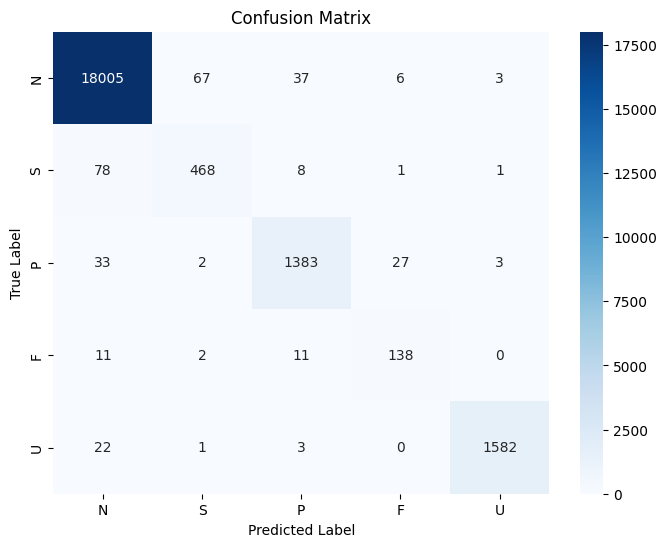

Train set Valuation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     64079
           1       1.00      0.99      1.00      7974
           2       1.00      1.00      1.00      7970
           3       1.00      1.00      1.00      7998
           4       1.00      1.00      1.00      7979

    accuracy                           1.00     96000
   macro avg       1.00      1.00      1.00     96000
weighted avg       1.00      1.00      1.00     96000



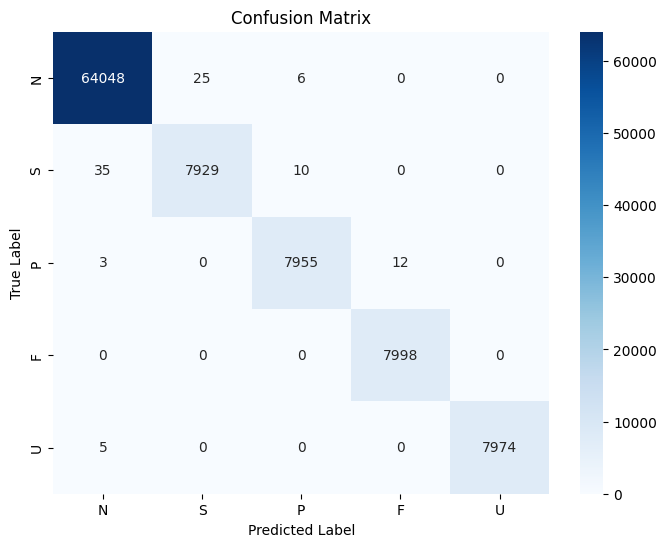

Val set Valuation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15921
           1       0.99      0.99      0.99      2026
           2       0.99      0.99      0.99      2030
           3       0.99      1.00      1.00      2002
           4       1.00      0.99      1.00      2021

    accuracy                           1.00     24000
   macro avg       0.99      0.99      0.99     24000
weighted avg       1.00      1.00      1.00     24000



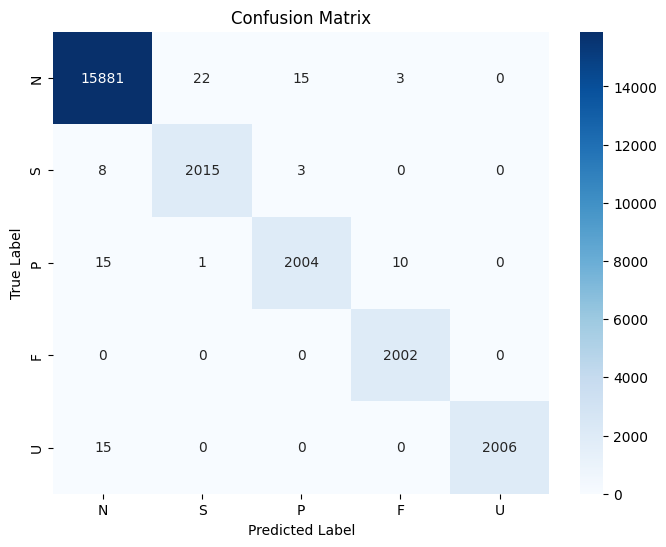

{'0': {'precision': 0.9976129153841322,
  'recall': 0.997487595000314,
  'f1-score': 0.9975502512562814,
  'support': 15921.0},
 '1': {'precision': 0.9887144259077527,
  'recall': 0.9945705824284304,
  'f1-score': 0.9916338582677166,
  'support': 2026.0},
 '2': {'precision': 0.9910979228486647,
  'recall': 0.987192118226601,
  'f1-score': 0.9891411648568608,
  'support': 2030.0},
 '3': {'precision': 0.9935483870967742,
  'recall': 1.0,
  'f1-score': 0.9967637540453075,
  'support': 2002.0},
 '4': {'precision': 1.0,
  'recall': 0.9925779317169718,
  'f1-score': 0.9962751427861932,
  'support': 2021.0},
 'accuracy': 0.9961666666666666,
 'macro avg': {'precision': 0.9941947302474649,
  'recall': 0.9943656454744634,
  'f1-score': 0.9942728342424718,
  'support': 24000.0},
 'weighted avg': {'precision': 0.9961726377946003,
  'recall': 0.9961666666666666,
  'f1-score': 0.9961665587887785,
  'support': 24000.0}}

In [11]:
predict_outcome = {0. : 'N', 1. : 'S', 2. : 'P', 3. : 'F', 4. : 'U'}
labels = [predict_outcome[i] for i in range(5)]
##Test set
# Evaluation
performance_evaluation(model, test_loader, labels, "Test set Valuation")

##Train set
# Evaluation
performance_evaluation(model, train_loader, labels, "Train set Valuation")

##Val set
# Evaluation
performance_evaluation(model, val_loader, labels, "Val set Valuation")

Test set Valuation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.87      0.84      0.85       556
           2       0.96      0.96      0.96      1448
           3       0.80      0.85      0.83       162
           4       1.00      0.98      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.92      0.93      0.92     21892
weighted avg       0.99      0.99      0.99     21892



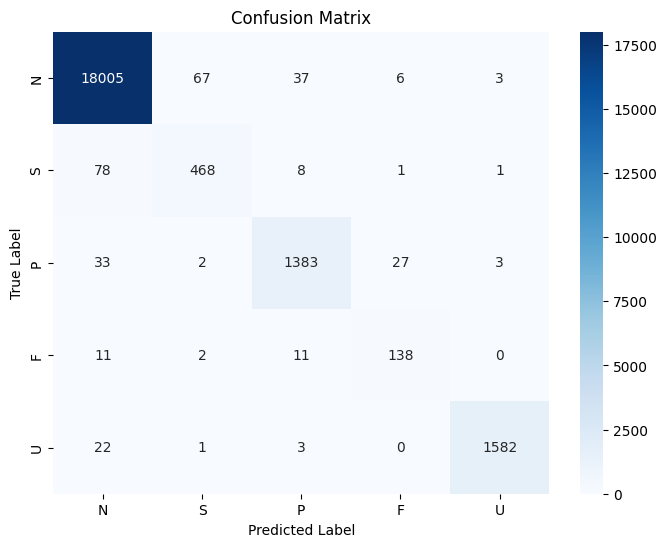

In [15]:
def performance_evaluation_save(model, labels_mapping,message_banner = ""):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    print(message_banner)
    print(classification_report(y_true, y_pred))

    # Generate classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_mapping, yticklabels=labels_mapping)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.savefig("confusion_matrix_reset_lstm.png")  # Saves to file

performance_evaluation_save(model, labels, "Test set Valuation")

In [12]:
path = "models_save/"
model_save = path + "CNN_Resnet_LSTM.pth"
#Save Trained Model:
torch.save(model.state_dict(), model_save)
print("Model saved successfully.")

Model saved successfully.
